In [1]:
from matplotlib.pyplot import *
from numpy             import *
from pandas            import *
from seaborn           import *

In [2]:
set        ()

In [3]:
Si01_Level_xstar = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si01_Level.tsv",sep="\t")
Si01_Level_xstar = Si01_Level_xstar.drop(columns="Unnamed: 0")

In [4]:
Electron         = []
Level            = []
Ionized          = []
Energy           = []
Parity           = []
NL               = []
J                = []
Configuration    = []
Si01_Translation = {}

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si01.en") as file:
    for line in file.readlines():
        line = line.split()
        for n in range(len(Si01_Level_xstar.index)-1):
            if line[5]==str(100*Si01_Level_xstar["N"][n]+Si01_Level_xstar["L"][n]) and line[6]==str(Si01_Level_xstar["2J+1"][n]-1):
                Electron                 += [line[0]]
                Level                    += [Si01_Level_xstar["Level"][n]]
                Ionized                  += [line[2]]
                Energy                   += [float(line[3])]
                Parity                   += [line[4]]
                NL                       += [line[5]]
                J                        += [line[6]]
                Configuration            += [" ".join(line[7:])]
                Si01_Translation[line[1]] = str(Si01_Level_xstar["Level"][n])

Si01_Level_monaco = DataFrame({"Electron":Electron, "Level":Level, "Ionized":Ionized, "Energy":Energy, "Parity":Parity, "NL":NL, "2J":J, "Configuration":Configuration})
Si01_Level_monaco = Si01_Level_monaco.sort_values(["Level"]).reset_index(drop=True)

In [5]:
Si01_Level_Index  = []
Si01_Level_Energy = []

for i in range(len(Si01_Level_xstar.index)):
    for j in range(len(Si01_Level_monaco.index)):
        if Si01_Level_xstar["Level"][i]==Si01_Level_monaco["Level"][j]:
            Si01_Level_Index  += [Si01_Level_xstar["Level"][i]]
            Si01_Level_Energy += [Si01_Level_xstar["Energy"][i]-Si01_Level_monaco["Energy"][j]]

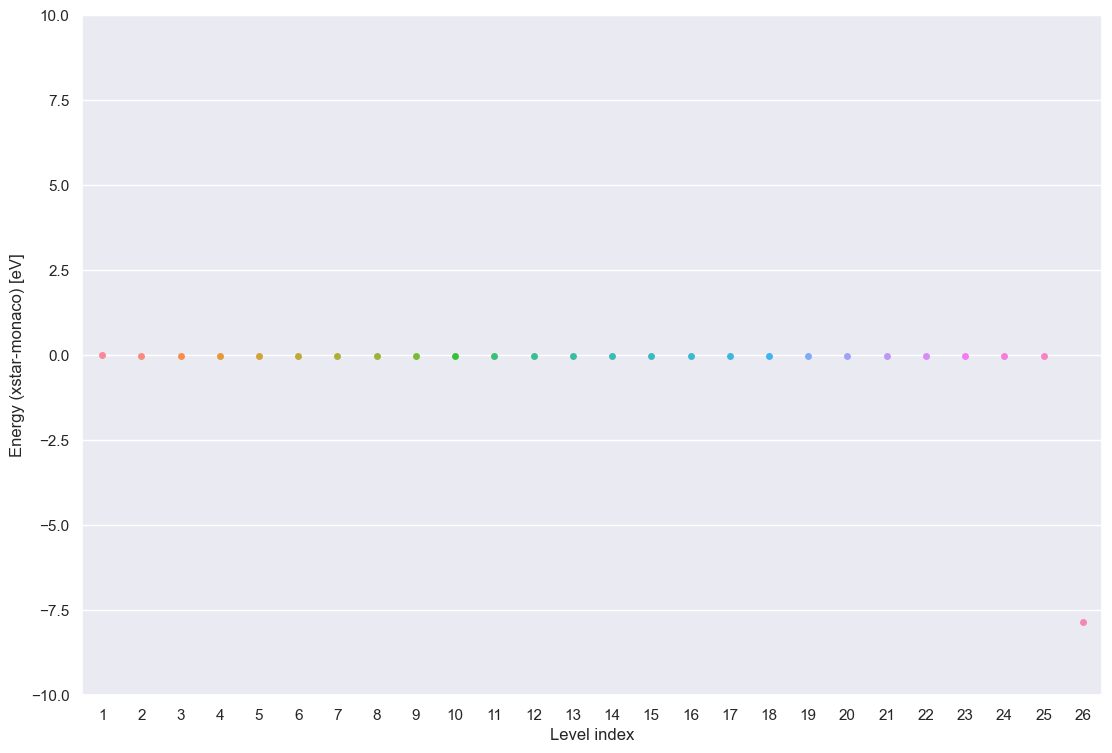

In [7]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+1,-1e+1,+1e+1])
swarmplot      (x=Si01_Level_Index, y=Si01_Level_Energy)
xlabel         ("Level index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("./figure/00.png")

In [13]:
Si01_Transition_xstar = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si01_Transition.tsv",sep="\t")
Si01_Transition_xstar = Si01_Transition_xstar.drop(columns="Unnamed: 0")
Si01_Transition_xstar

,Z,Ion,Initial Level,Final Level,Energy,Strength,Rate
0,14,105,2,1,2004.25900,0.0,2.406770e+13
1,14,105,3,1,2006.01400,0.0,2.406770e+13
2,14,105,5,1,2376.02700,0.0,6.425310e+12
3,14,105,5,4,371.70220,0.0,8.623930e+11
4,14,105,6,1,2376.54700,0.0,6.425310e+12
...,...,...,...,...,...,...,...
128,14,105,30,16,84.67897,0.0,5.273790e+10
129,14,105,30,22,24.69472,0.0,4.247730e+10
130,14,105,30,23,24.67612,0.0,4.247730e+10
131,14,105,31,24,24.67612,0.0,6.318930e+10


In [14]:
Initial_Level = []
Final_Level   = []
Energy        = []
Strength      = []
Rate          = []

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si01.tr") as file:
    for line in file.readlines():
        line = line.split()
        if line[0] in Si01_Translation.keys() and line[2] in Si01_Translation.values():
            Initial_Level += [int(Si01_Translation[line[0]])]
            Final_Level   += [int(Si01_Translation[line[2]])]
            Energy        += [float(line[4])]
            Strength      += [float(line[5])]
            Rate          += [float(line[6])]

Si01_Transition_monaco = DataFrame({"Initial Level":Initial_Level, "Final Level":Final_Level, "Energy":Energy, "Strength":Strength, "Rate":Rate})
Si01_Transition_monaco = Si01_Transition_monaco.sort_values(["Initial Level", "Final Level"]).reset_index(drop=True)
Si01_Transition_monaco

,Initial Level,Final Level,Energy,Strength,Rate
0,3,2,1.754814,3.810633e-07,2.545883e+01
1,3,4,1.691762,3.793102e-03,2.355334e+05
2,4,2,0.063051,7.031455e-05,1.212951e+01
3,5,4,371.717700,1.448457e-01,8.684433e+11
4,6,4,372.237800,2.864270e-01,8.610614e+11
...,...,...,...,...,...
90,26,6,222.365900,3.097575e-03,1.329223e+10
91,26,10,92.834170,1.232942e-02,4.610709e+09
92,26,11,92.614830,1.259604e-02,9.376359e+09
93,26,17,32.669240,7.448735e-02,3.449610e+09


In [15]:
Si01_Transition_Index    = []
Si01_Transition_Energy   = []
Si01_Transition_Strength = []
Si01_Transition_Rate     = []

for i in range(len(Si01_Transition_xstar.index)):
    for j in range(len(Si01_Transition_monaco.index)):
        if Si01_Transition_xstar["Initial Level"][i]==Si01_Transition_monaco["Initial Level"][j] and Si01_Transition_xstar["Final Level"][i]==Si01_Transition_monaco["Final Level"][j]:
            Si01_Transition_Index    += ["{0:04d}".format(100*Si01_Transition_xstar["Initial Level"][i]+Si01_Transition_xstar["Final Level"][i])]
            Si01_Transition_Energy   += [Si01_Transition_xstar["Energy"][i]-Si01_Transition_monaco["Energy"][j]]
            Si01_Transition_Strength += [Si01_Transition_xstar["Strength"][i]-Si01_Transition_monaco["Strength"][j]]
            Si01_Transition_Rate     += [Si01_Transition_xstar["Rate"][i]-Si01_Transition_monaco["Rate"][j]]

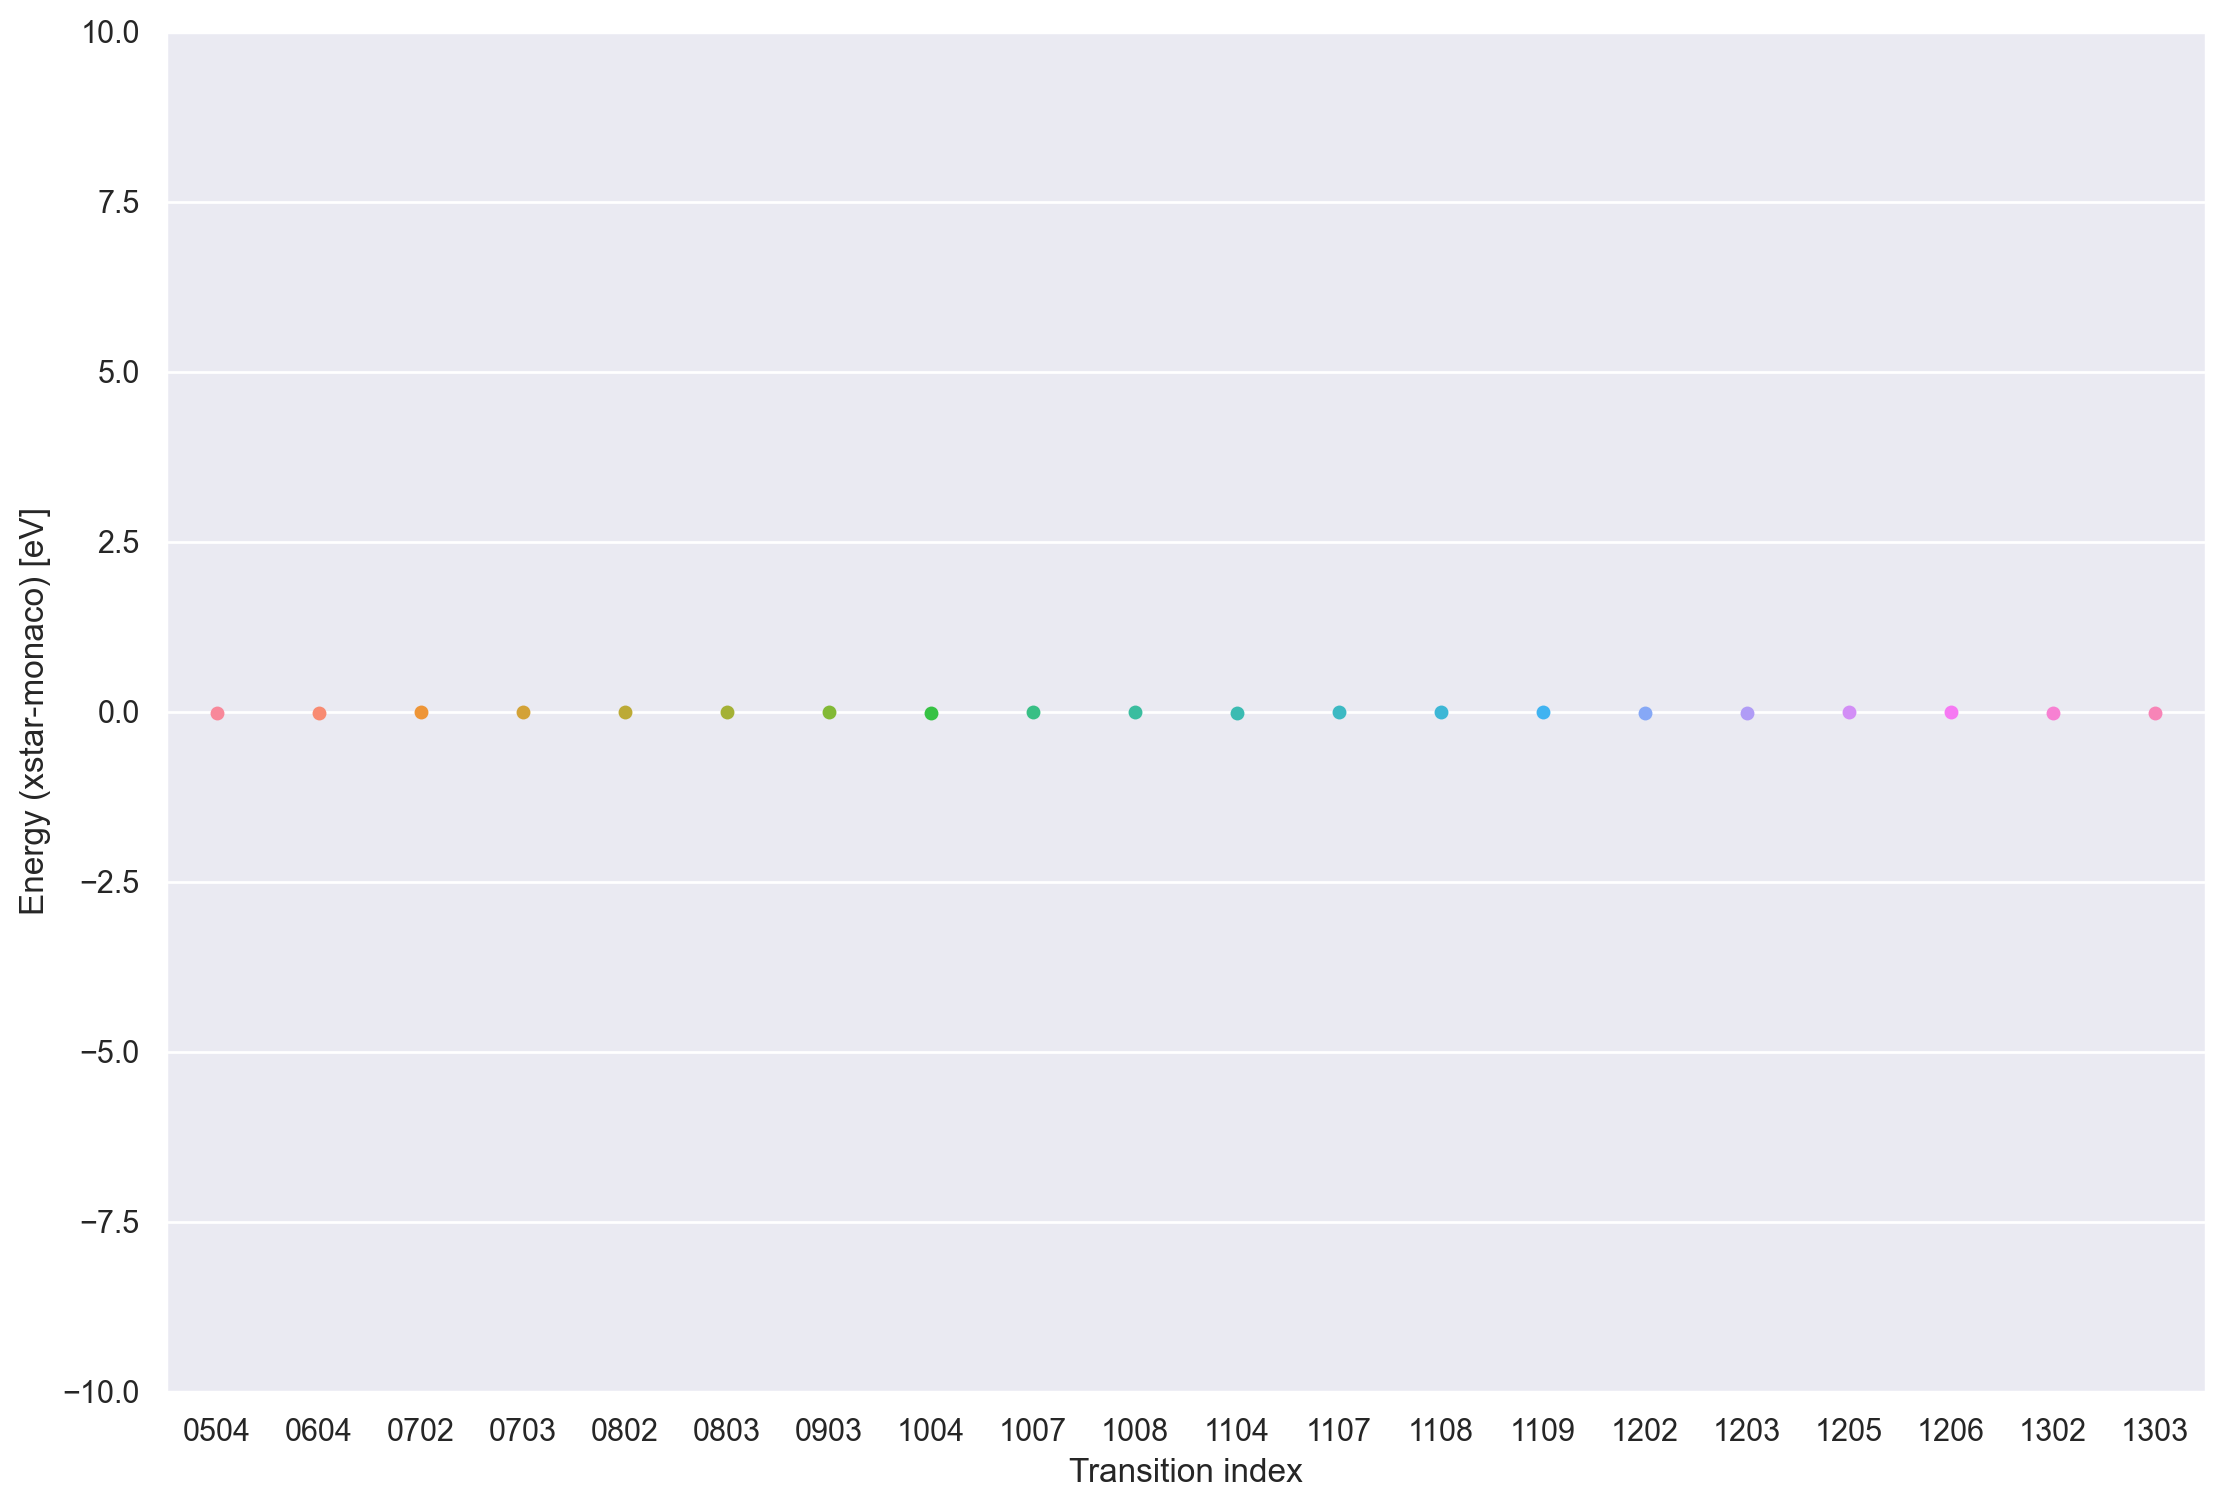

In [16]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si01_Transition_Index[0:20], y=Si01_Transition_Energy[0:20])
xlabel         ("Transition index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("./figure/01.png")

In [17]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si01_Transition_Index[20:40], y=Si01_Transition_Energy[20:40])
xlabel         ("Transition index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("./figure/02.png")

In [ ]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si01_Transition_Index[40:60], y=Si01_Transition_Energy[40:60])
xlabel         ("Transition index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("./figure/03.png")

In [ ]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si01_Transition_Index[60:80], y=Si01_Transition_Energy[60:80])
xlabel         ("Transition index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("./figure/04.png")

In [ ]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+3,-4e+12,+4e+12])
swarmplot      (x=Si01_Transition_Index[0:20], y=Si01_Transition_Rate[0:20])
xlabel         ("Transition index")
ylabel         ("Rate (xstar-monaco)")
savefig        ("./figure/05.png")

In [ ]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+3,-4e+12,+4e+12])
swarmplot      (x=Si01_Transition_Index[20:40], y=Si01_Transition_Rate[20:40])
xlabel         ("Transition index")
ylabel         ("Rate (xstar-monaco)")
savefig        ("./figure/06.png")

In [ ]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+3,-4e+12,+4e+12])
swarmplot      (x=Si01_Transition_Index[40:60], y=Si01_Transition_Rate[40:60])
xlabel         ("Transition index")
ylabel         ("Rate (xstar-monaco)")
savefig        ("./figure/07.png")

In [ ]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([0e+0,3e+3,-4e+12,+4e+12])
swarmplot      (x=Si01_Transition_Index[60:80], y=Si01_Transition_Rate[60:80])
xlabel         ("Transition index")
ylabel         ("Rate (xstar-monaco)")
savefig        ("./figure/08.png")

# Si01 Recombination

## Load Xstar Data

In [ ]:
Si01_Recombination_xstar = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si01_Recombination.tsv",sep="\t")
Si01_Recombination_xstar = Si01_Recombination_xstar.drop(columns="Unnamed: 0")
Si01_Recombination_xstar.head()

## Load Monaco Data

In [ ]:
Temperature = []
Rate        = []

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si01.rates") as file:
    for line in file.readlines():
        line         = line.split()
        Temperature += [float(line[1])]
        Rate        += [float(line[2])]

Si01_Recombination_monaco = DataFrame({"Temperature":Temperature, "Rate":Rate})
Si01_Recombination_monaco.head()

## Plot Rate

In [ ]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([-1e+0,+5e+0,-15e+0,-9e+0])
plot           (log10(Si01_Recombination_monaco["Temperature"]), log10(Si01_Recombination_monaco["Rate"]), color="tomato"    , label="Monaco")
plot           (log10(Si01_Recombination_xstar["Temperature"]) , log10(Si01_Recombination_xstar["Rate"]) , color="dodgerblue", label="XSTAR")
legend         (fontsize=16, loc="upper right")
xlabel         ("log T/eV")
ylabel         ("log Rate")
savefig        ("./figure/09.png")

# Fe01 Recombination

## Load Xstar Data

In [ ]:
Xstar_Recombination_Fe01 = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Fe/Fe01_Recombination.tsv",sep="\t")
Xstar_Recombination_Fe01 = Xstar_Recombination_Fe01.drop(columns="Unnamed: 0")
Xstar_Recombination_Fe01

## Load Monaco Data

In [ ]:
Temperature = []
Rate        = []

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Fe/Fe01.rates") as file:
    for line in file.readlines():
        line         = line.split()
        Temperature += [float(line[1])]
        Rate        += [float(line[2])]

Monaco_Recombination_Fe01 = DataFrame({"Temperature":Temperature, "Rate":Rate})
Monaco_Recombination_Fe01.head()

In [ ]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.10, bottom=0.10, right=0.95, top=0.95)
axis           ([+0e+0,+4e+0,-13e+0,-9e+0])
plot           (log10(Monaco_Recombination_Fe01["Temperature"]), log10(Monaco_Recombination_Fe01["Rate"]), color="tomato"    , label="Monaco")
plot           (log10(Xstar_Recombination_Fe01["Temperature"]) , log10(Xstar_Recombination_Fe01["Rate"]) , color="dodgerblue", label="XSTAR")
legend         (fontsize=16, loc="upper right")
xlabel         ("log T/eV")
ylabel         ("log Rate")
savefig        ("./figure/10.png")